In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score


# LOAD DATA

In [48]:
df = pd.read_csv('train.txt', sep=';', header=None, names=['text', 'emotion'])

In [49]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [50]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [51]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
i = 0
for emotion in unique_emotions:
    emotion_numbers[emotion] = i
    i += 1

df['emotion'] = df['emotion'].map(emotion_numbers)

# TEXT CLEANING

In [52]:
df

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,5
15998,i feel like this was such a rude comment and i...,1


In [53]:
df['text'] = df['text'].apply(lambda x: x.lower())

In [54]:
import string
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [55]:
df['text'] = df['text'].apply(remove_punctuation)

In [56]:
def remove_nums(text):
    new = ""
    for i in text:
        if not i.isdigit():
            new += i
    return new

df['text'] = df['text'].apply(remove_nums)

In [57]:
def remove_emojis(text):
    new = ""
    for i in text:
        if i.isascii():
            new += i
    return new

df['text'] = df['text'].apply(remove_emojis)

In [58]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [59]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [60]:
stop_words = set(stopwords.words('english'))
len(stop_words)

198

In [61]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [62]:
def remove(text):
    words = word_tokenize(text)
    cleaned = []
    for i in words:
        if i not in stop_words:
            cleaned.append(i)
    return " ".join(cleaned)

In [63]:
df['text'] = df['text'].apply(remove)

In [64]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [65]:
from sklearn.feature_extraction.text import CountVectorizer

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TRAIN / TEST SPLIT

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.2, random_state=42)

In [69]:
X_train

676      refers course though cant help feeling somehow...
12113                im starting feel im suffering fatigue
7077     feel like probably would liked book little bit...
13005                                  really feel awkward
12123    im feeling little grumpy today lame weather te...
                               ...                        
13418    love leave reader feeling confused slightly de...
5390                                         feel delicate
860                          starting feel little stressed
15795             feel stressed tired worn shape neglected
7270         feel someone rude wrongly done something lose
Name: text, Length: 12800, dtype: str

In [70]:
X_test

8756                             ive made week feel beaten
4660                              feel strategy worthwhile
6095                     feel worthless weak say want find
304                                        feel clever nov
8241                      im moved ive feeling kind gloomy
                               ...                        
15578    feel useful pulpit find ironic often question ...
5746             dried bladders ready day im feeling brave
6395                             feel thrilled matter days
7624     woke morning text mr c declaring walking work ...
15245                                            feel dumb
Name: text, Length: 3200, dtype: str

# BASELINE VECTORIZERS (BOW & TF-IDF)

In [71]:
bow_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

In [72]:
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# BASELINE MODELS

## Naive Bayes

In [73]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [74]:
nb_bow = MultinomialNB().fit(X_train_bow, y_train)
pred_nb_bow = nb_bow.predict(X_test_bow)
acc_nb_bow = accuracy_score(y_test, pred_nb_bow)
print("Accuracy Naive Bayes BOW:", acc_nb_bow)
print(classification_report(y_test, pred_nb_bow))
 
nb_tfidf = MultinomialNB().fit(X_train_tfidf, y_train)
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
acc_nb_tfidf = accuracy_score(y_test, pred_nb_tfidf)
print("Accuracy Naive Bayes TF-IDF:", acc_nb_tfidf)
print(classification_report(y_test, pred_nb_tfidf))

Accuracy Naive Bayes BOW: 0.7678125
              precision    recall  f1-score   support

           0       0.75      0.95      0.84       946
           1       0.89      0.63      0.74       427
           2       0.93      0.26      0.41       296
           3       1.00      0.05      0.10       113
           4       0.85      0.57      0.68       397
           5       0.73      0.96      0.83      1021

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200

Accuracy Naive Bayes TF-IDF: 0.6609375
              precision    recall  f1-score   support

           0       0.70      0.93      0.80       946
           1       0.93      0.29      0.44       427
           2       1.00      0.03      0.06       296
           3       1.00      0.01      0.02       113
           4       0.92      0.22      0.36       397
           5       0.60      0.99      0.74      1021

  

## Logistic Regression

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
lr_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_train_tfidf, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)
acc_lr_tfidf = accuracy_score(y_test, pred_lr_tfidf)
print("Accuracy Logistic Regression TF-IDF:", acc_lr_tfidf)
print(classification_report(y_test, pred_lr_tfidf))
 
lr_bow = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_train_bow, y_train)
pred_lr_bow = lr_bow.predict(X_test_bow)
acc_lr_bow = accuracy_score(y_test, pred_lr_bow)
print("Accuracy Logistic Regression BOW:", acc_lr_bow)
print(classification_report(y_test, pred_lr_bow))

Accuracy Logistic Regression TF-IDF: 0.8859375
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       946
           1       0.87      0.90      0.89       427
           2       0.76      0.91      0.83       296
           3       0.65      0.85      0.74       113
           4       0.84      0.83      0.84       397
           5       0.93      0.89      0.91      1021

    accuracy                           0.89      3200
   macro avg       0.83      0.88      0.85      3200
weighted avg       0.89      0.89      0.89      3200

Accuracy Logistic Regression BOW: 0.8890625
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       946
           1       0.87      0.89      0.88       427
           2       0.77      0.90      0.83       296
           3       0.66      0.88      0.75       113
           4       0.85      0.83      0.84       397
           5       0.94      0.90      0.

## SVM

In [77]:
from sklearn.svm import LinearSVC

In [78]:
svm_tfidf = LinearSVC(max_iter=2000, class_weight='balanced').fit(X_train_tfidf, y_train)
pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
acc_svm_tfidf = accuracy_score(y_test, pred_svm_tfidf)
print("Accuracy SVM TF-IDF:", acc_svm_tfidf)
print(classification_report(y_test, pred_svm_tfidf))
 
svm_bow = LinearSVC(max_iter=2000, class_weight='balanced').fit(X_train_bow, y_train)
pred_svm_bow = svm_bow.predict(X_test_bow)
acc_svm_bow = accuracy_score(y_test, pred_svm_bow)
print("Accuracy SVM BOW:", acc_svm_bow)
print(classification_report(y_test, pred_svm_bow))

Accuracy SVM TF-IDF: 0.8921875
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       946
           1       0.88      0.89      0.89       427
           2       0.78      0.83      0.80       296
           3       0.81      0.74      0.77       113
           4       0.85      0.85      0.85       397
           5       0.92      0.92      0.92      1021

    accuracy                           0.89      3200
   macro avg       0.86      0.86      0.86      3200
weighted avg       0.89      0.89      0.89      3200

Accuracy SVM BOW: 0.88875
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       946
           1       0.89      0.89      0.89       427
           2       0.79      0.82      0.81       296
           3       0.76      0.77      0.77       113
           4       0.84      0.85      0.84       397
           5       0.91      0.91      0.91      1021

    accuracy        

# VISUALIZATIONS

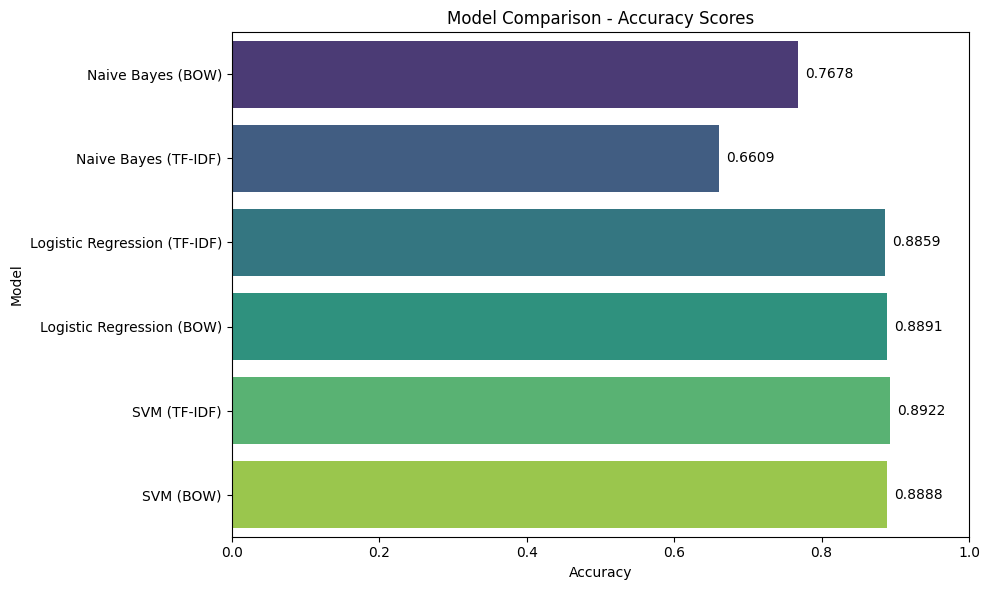

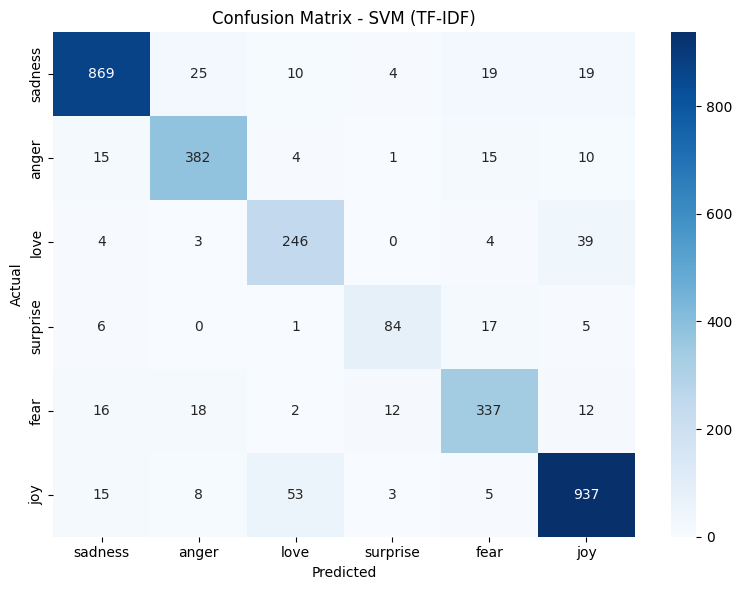

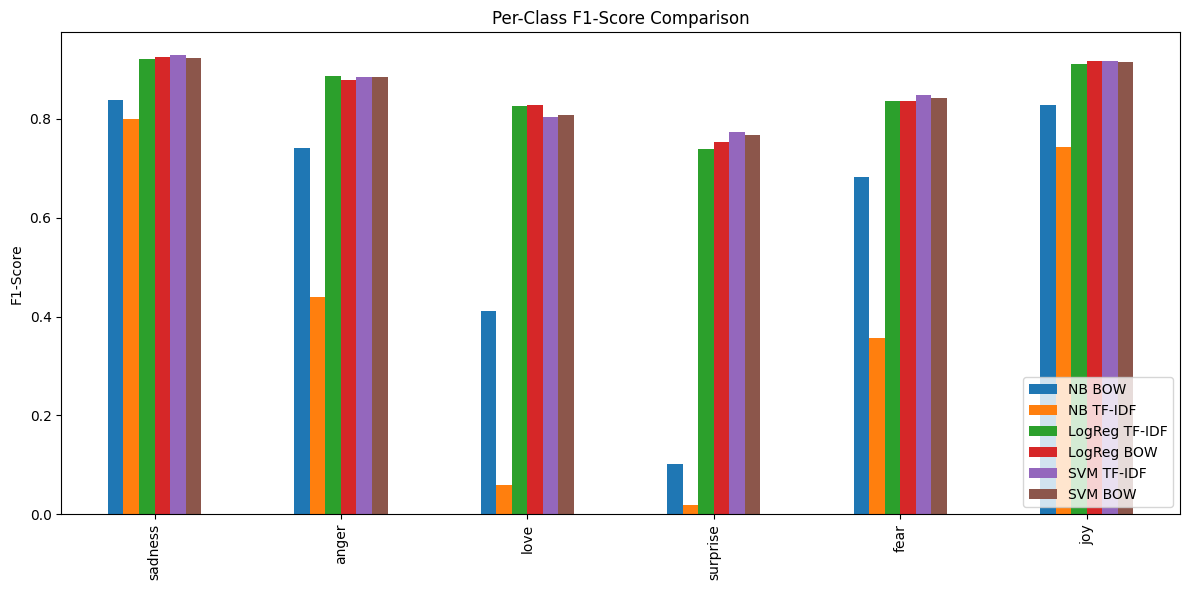

In [79]:
results = {
    'Naive Bayes (BOW)': acc_nb_bow,
    'Naive Bayes (TF-IDF)': acc_nb_tfidf,
    'Logistic Regression (TF-IDF)': acc_lr_tfidf,
    'Logistic Regression (BOW)': acc_lr_bow,
    'SVM (TF-IDF)': acc_svm_tfidf,
    'SVM (BOW)': acc_svm_bow,
}
 
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.values()), y=list(results.keys()), hue=list(results.keys()), palette='viridis', legend=False)
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model Comparison - Accuracy Scores')
plt.xlim(0, 1)
for i, v in enumerate(results.values()):
    plt.text(v + 0.01, i, f"{v:.4f}", color='black', va='center')
plt.tight_layout()
plt.show()
 
cm = confusion_matrix(y_test, pred_svm_tfidf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_emotions, yticklabels=unique_emotions)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM (TF-IDF)')
plt.tight_layout()
plt.show()
 
models_preds = {
    'NB BOW': pred_nb_bow,
    'NB TF-IDF': pred_nb_tfidf,
    'LogReg TF-IDF': pred_lr_tfidf,
    'LogReg BOW': pred_lr_bow,
    'SVM TF-IDF': pred_svm_tfidf,
    'SVM BOW': pred_svm_bow,
}
f1_data = {name: f1_score(y_test, pred, average=None) for name, pred in models_preds.items()}
f1_df = pd.DataFrame(f1_data, index=unique_emotions)
f1_df.plot(kind='bar', figsize=(12, 6))
plt.ylabel('F1-Score')
plt.title('Per-Class F1-Score Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
 

# PIPELINE TUNING (vectorizer + model together) - FINAL MODEL SOURCE

In [97]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer()),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('svm', LinearSVC(max_iter=2000)),
])

param_grid_pipeline = {
    'tfidf__max_features': [1500, 3000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [8, 10],
    'svm__C': [0.001, 0.01, 0.1, 1],
    'svm__class_weight': [
        'balanced',
        {0: 1, 1: 2, 2: 1, 3: 1, 4: 1, 5: 1},
    ]
}

# --- Grid Search version ---
grid_search_pipeline = GridSearchCV(
    pipeline, param_grid_pipeline,
    cv=5, scoring='f1_macro', n_jobs=-1, verbose=2
)
grid_search_pipeline.fit(X_train, y_train)
print("Best Parameters (Grid):", grid_search_pipeline.best_params_)
print("Best CV Score (Grid):", grid_search_pipeline.best_score_)

best_pipeline_grid = grid_search_pipeline.best_estimator_
y_pred_grid = best_pipeline_grid.predict(X_test)
print('Best Pipeline Results Using Grid Search:\n', classification_report(y_test, y_pred_grid))

# --- Randomized Search version ---
random_search_pipeline = RandomizedSearchCV(
    pipeline, param_grid_pipeline,
    n_iter=15, cv=5, scoring='f1_macro',
    n_jobs=-1, verbose=2, random_state=42
)
random_search_pipeline.fit(X_train, y_train)
print("Best Parameters (Randomized):", random_search_pipeline.best_params_)
print("Best CV Score (Randomized):", random_search_pipeline.best_score_)

best_pipeline_random = random_search_pipeline.best_estimator_
y_pred_random = best_pipeline_random.predict(X_test)
print('Best Pipeline Results Using Randomized Search:\n', classification_report(y_test, y_pred_random))

# Overfitting check for both
train_acc_grid = accuracy_score(y_train, best_pipeline_grid.predict(X_train))
test_acc_grid = accuracy_score(y_test, y_pred_grid)
print(f"[Grid Pipeline]       Train Acc: {train_acc_grid:.4f} | Test Acc: {test_acc_grid:.4f}")

train_acc_random = accuracy_score(y_train, best_pipeline_random.predict(X_train))
test_acc_random = accuracy_score(y_test, y_pred_random)
print(f"[Randomized Pipeline] Train Acc: {train_acc_random:.4f} | Test Acc: {test_acc_random:.4f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters (Grid): {'svm__C': 0.1, 'svm__class_weight': 'balanced', 'tfidf__max_features': 3000, 'tfidf__min_df': 8, 'tfidf__ngram_range': (1, 2)}
Best CV Score (Grid): 0.8551705549872046
Best Pipeline Results Using Grid Search:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       946
           1       0.88      0.88      0.88       427
           2       0.76      0.94      0.84       296
           3       0.69      0.96      0.81       113
           4       0.85      0.84      0.84       397
           5       0.96      0.90      0.93      1021

    accuracy                           0.90      3200
   macro avg       0.85      0.91      0.87      3200
weighted avg       0.91      0.90      0.90      3200

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters (Randomized): {'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 8, 'tfidf__max_featur

In [98]:
print(grid_search_pipeline.best_params_)
print(random_search_pipeline.best_params_)

{'svm__C': 0.1, 'svm__class_weight': 'balanced', 'tfidf__max_features': 3000, 'tfidf__min_df': 8, 'tfidf__ngram_range': (1, 2)}
{'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 8, 'tfidf__max_features': 3000, 'svm__class_weight': 'balanced', 'svm__C': 0.1}


# PROBABILITY CALIBRATION

In [99]:
calibrated_model = CalibratedClassifierCV(best_pipeline_grid, cv=5, method='sigmoid')
calibrated_model.fit(X_train, y_train)
 
y_pred_calibrated = calibrated_model.predict(X_test)
print("Calibrated Test Accuracy:", accuracy_score(y_test, y_pred_calibrated))
print(classification_report(y_test, y_pred_calibrated))

Calibrated Test Accuracy: 0.8971875
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       946
           1       0.89      0.85      0.87       427
           2       0.80      0.88      0.84       296
           3       0.76      0.92      0.83       113
           4       0.86      0.83      0.85       397
           5       0.92      0.92      0.92      1021

    accuracy                           0.90      3200
   macro avg       0.86      0.89      0.87      3200
weighted avg       0.90      0.90      0.90      3200



# SAVE FINAL MODEL

In [100]:
import joblib

In [101]:
joblib.dump(calibrated_model, 'emotion_model.pkl')
joblib.dump(emotion_numbers, 'emotion_labels.pkl')
print("Saved: emotion_model.pkl, emotion_labels.pkl")

Saved: emotion_model.pkl, emotion_labels.pkl


In [102]:
train_acc_cal = accuracy_score(y_train, calibrated_model.predict(X_train))
print(f"[Calibrated] Train Acc: {train_acc_cal:.4f} | Test Acc: {accuracy_score(y_test, y_pred_calibrated):.4f}")

[Calibrated] Train Acc: 0.9341 | Test Acc: 0.8972


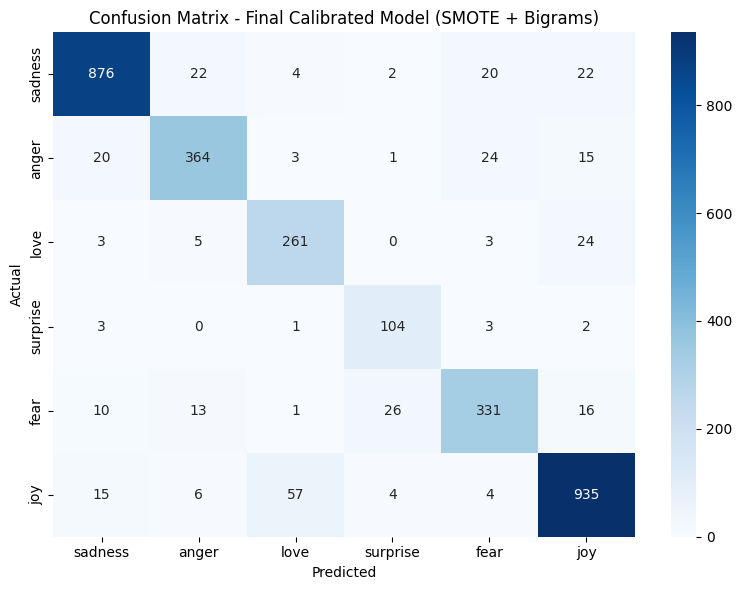

In [103]:
cm_new = confusion_matrix(y_test, y_pred_calibrated)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_emotions, yticklabels=unique_emotions)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Calibrated Model (SMOTE + Bigrams)')
plt.tight_layout()
plt.show()

In [104]:
print("Unique predictions:", set(y_pred_calibrated))
print("Test Accuracy:", accuracy_score(y_test, y_pred_calibrated))
print("Baseline SVM Accuracy:", acc_svm_tfidf)

Unique predictions: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}
Test Accuracy: 0.8971875
Baseline SVM Accuracy: 0.8921875


In [105]:
print(calibrated_model.get_params()['estimator'])

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=3000, min_df=8,
                                 ngram_range=(1, 2))),
                ('smote', SMOTE(k_neighbors=3, random_state=42)),
                ('svm',
                 LinearSVC(C=0.1, class_weight='balanced', max_iter=2000))])


In [106]:
print(grid_search_pipeline.best_params_)

{'svm__C': 0.1, 'svm__class_weight': 'balanced', 'tfidf__max_features': 3000, 'tfidf__min_df': 8, 'tfidf__ngram_range': (1, 2)}


In [107]:
y_pred_calibrated = calibrated_model.predict(X_test)

cm_check = confusion_matrix(y_test, y_pred_calibrated)
print(cm_check)

[[876  22   4   2  20  22]
 [ 20 364   3   1  24  15]
 [  3   5 261   0   3  24]
 [  3   0   1 104   3   2]
 [ 10  13   1  26 331  16]
 [ 15   6  57   4   4 935]]


In [108]:
import numpy as np

# Fresh comparison
print("Same as baseline?", np.array_equal(y_pred_calibrated, pred_svm_tfidf))
print("Matching predictions:", (y_pred_calibrated == pred_svm_tfidf).sum(), "/", len(y_pred_calibrated))

# Recompute confusion matrix FRESH, right here
cm_check = confusion_matrix(y_test, y_pred_calibrated)
print(cm_check)

# Also recompute accuracy fresh
print("Fresh Test Accuracy:", accuracy_score(y_test, y_pred_calibrated))

Same as baseline? False
Matching predictions: 2947 / 3200
[[876  22   4   2  20  22]
 [ 20 364   3   1  24  15]
 [  3   5 261   0   3  24]
 [  3   0   1 104   3   2]
 [ 10  13   1  26 331  16]
 [ 15   6  57   4   4 935]]
Fresh Test Accuracy: 0.8971875


In [110]:
print("REAL CHECK ---")
diff_count = (y_pred_calibrated != pred_svm_tfidf).sum()
print("Different predictions:", diff_count)

fresh_cm = confusion_matrix(y_test, y_pred_calibrated)
print("Fresh CM diagonal:", fresh_cm.diagonal())
print("Fresh CM sum:", fresh_cm.sum())

REAL CHECK ---
Different predictions: 253
Fresh CM diagonal: [876 364 261 104 331 935]
Fresh CM sum: 3200


In [109]:
old_cm = confusion_matrix(y_test, pred_svm_tfidf)
new_cm = confusion_matrix(y_test, y_pred_calibrated)
print("Are matrices identical?", np.array_equal(old_cm, new_cm))
print("Cell-by-cell difference:")
print(new_cm - old_cm)

Are matrices identical? False
Cell-by-cell difference:
[[  7  -3  -6  -2   1   3]
 [  5 -18  -1   0   9   5]
 [ -1   2  15   0  -1 -15]
 [ -3   0   0  20 -14  -3]
 [ -6  -5  -1  14  -6   4]
 [  0  -2   4   1  -1  -2]]


In [111]:
import os
from datetime import datetime
print("Model saved at:", datetime.fromtimestamp(os.path.getmtime('emotion_model.pkl')))

Model saved at: 2026-08-31 16:57:58.742953
